In [1]:
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers

X_train = np.load("X_train.npy")
X_test = np.load("X_test.npy")
y_train = np.load("y_train.npy")
y_test = np.load("y_test.npy")

print(X_train.shape, X_test.shape)

(916, 60, 8) (229, 60, 8)


In [2]:
model = keras.Sequential([
    layers.LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    layers.LSTM(32),
    layers.Dense(16, activation="relu"),
    layers.Dense(1)
])

model.compile(optimizer="adam", loss="mean_squared_error")
model.summary()

c:\Users\scghl\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,649 (123.63 KB)

 Trainable params: 31,649 (123.63 KB)

 Non-trainable params: 0 (0.00 B)

In [3]:
history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=50,
    batch_size=32
)

Epoch 1/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0079 - val_loss: 3.6850e-04
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0011 - val_loss: 7.3874e-04
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 7.8575e-04 - val_loss: 0.0018
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 6.9762e-04 - val_loss: 0.0018
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 6.6337e-04 - val_loss: 0.0013
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 6.4713e-04 - val_loss: 0.0011
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 6.2655e-04 - val_loss: 0.0023
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 6.5220e-04 - val_loss: 0.0012
Epoch 9/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 6.6575e-04 - val_loss: 7.1685e-04
Epoch 10/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 6.0054e-04 - val_loss: 0.0010
Epoch 11/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 5.8467e-04 - val_loss: 0.0014
Epoch 12/50
26/

In [4]:
model.save("sp500_lstm_model.keras")

Matplotlib is building the font cache; this may take a moment.


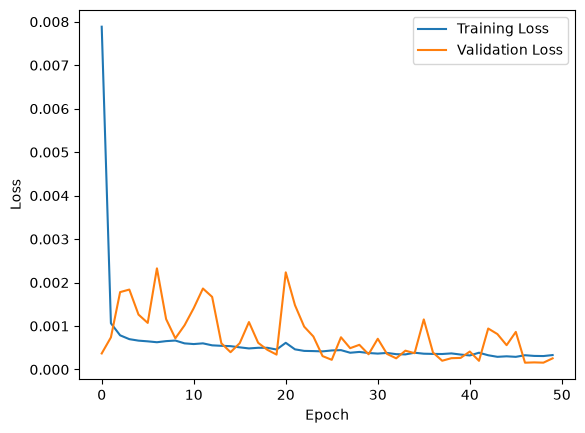

In [7]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()